<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Internship_Fed_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Model Inversion (Feature Reconstruction) Attack
## Exploiting Neural Memory Across Data Modalities

**Objective:**
This notebook executes an optimization-based Model Inversion attack. We assume the role of an adversary sitting on the central Federated Learning server. We have intercepted the `state_dicts` (weights) sent by the edge clients.

**The Attack Mechanism (Activation Maximization):**
We freeze the intercepted model weights. We then feed pure, random noise into the network and use gradient descent to *update the input noise* (instead of the model). We optimize the noise to maximize the network's confidence in a specific target class.

**Hypothesis:**
1. **MNIST (Integrated Data):** The model will reconstruct recognizable spatial patterns (pixels) of the target digit.
2. **Tabular (Scattered Data):** The model will reconstruct the "archetypal" standardized feature vector of a specific diagnosis, revealing the exact numerical thresholds the model memorized to make decisions.

## Libraies and Mounting from Dive

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

In [27]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Architecture

In [28]:
class FourLayerNet(nn.Module):
    def __init__(self):
        super(FourLayerNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)

In [29]:
class TabularNet(nn.Module):
    def __init__(self):
        super(TabularNet, self).__init__()
        self.fc1 = nn.Linear(30, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

## Inverting Integrated Data (MNIST)

We will load the `fedavg_mnist_weights.pth` file and target the digit "3". The optimizer will push a random pixel grid until the network is absolutely convinced it is looking at a 3.

In [30]:
# 1. Load the intercepted weights
mnist_model = FourLayerNet()
mnist_model.load_state_dict(torch.load('/content/drive/MyDrive/fedavg_mnist_weights.pth'))
mnist_model.eval()

# Freeze the network (we are attacking the input, not training the model)
for param in mnist_model.parameters():
    param.requires_grad = False

In [31]:
target_class_mnist = 3

In [32]:
# 2. Initialize pure noise (requires_grad=True allows us to optimize the pixels)
dummy_image = torch.randn(1, 1, 28, 28, requires_grad=True)
optimizer_mnist = torch.optim.Adam([dummy_image], lr=0.1)

In [33]:
# 3. Optimization Loop
for iteration in range(2000):
    optimizer_mnist.zero_grad()
    output = mnist_model(dummy_image)

    # Maximize target class confidence by minimizing its negative
    loss = -output[0, target_class_mnist]
    loss.backward()
    optimizer_mnist.step()

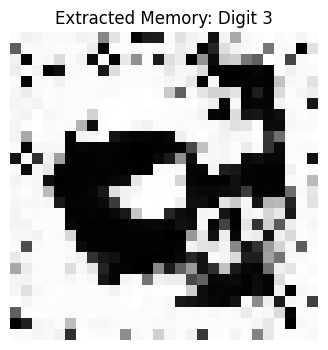

In [34]:
# 4. Visualization
reconstructed_image = dummy_image.detach().numpy().reshape(28, 28)
plt.figure(figsize=(4,4))
plt.imshow(reconstructed_image, cmap='gray')
plt.title(f"Extracted Memory: Digit {target_class_mnist}")
plt.axis('off')
plt.show()

In [35]:
# 5. Verification (Did we trick the model?)
recon_tensor = torch.tensor(reconstructed_image).view(1, 1, 28, 28)
with torch.no_grad():
    raw_output = mnist_model(recon_tensor)
    probabilities = F.softmax(raw_output, dim=1)
    predicted_class = torch.argmax(probabilities).item()
    confidence = probabilities[0, predicted_class].item() * 100

print(f"MNIST Verification | Target: {target_class_mnist} | Model Predicts: {predicted_class} | Confidence: {confidence:.2f}%\n")

MNIST Verification | Target: 3 | Model Predicts: 3 | Confidence: 100.00%



## Inverting Scattered Data (Breast Cancer)

We will load the `fedavg_tabular_weights.pth` file. The Breast Cancer dataset has 30 continuous features and 2 classes (0: Malignant, 1: Benign).

Instead of generating an image, the optimizer will generate a 1D vector of 30 numbers. Because we scaled the training data, these numbers represent standard deviations. We will plot them as a bar chart to see what the model considers the "perfect" malignant tumor profile.

In [36]:
# 1. Load the intercepted weights
tabular_model = TabularNet()
tabular_model.load_state_dict(torch.load('/content/drive/MyDrive/fedavg_tabular_weights.pth'))
tabular_model.eval()

# Freeze the network
for param in tabular_model.parameters():
    param.requires_grad = False

In [37]:
# Target Class 0 (Malignant) or 1 (Benign)
target_class_tab = 0

In [38]:
# 2. Initialize pure noise vector for 30 features
dummy_features = torch.randn(1, 30, requires_grad=True)
optimizer_tab = torch.optim.Adam([dummy_features], lr=0.1)

In [39]:
# 3. Optimization Loop
for iteration in range(2000):
    optimizer_tab.zero_grad()
    output = tabular_model(dummy_features)
    loss = -output[0, target_class_tab]
    loss.backward()
    optimizer_tab.step()

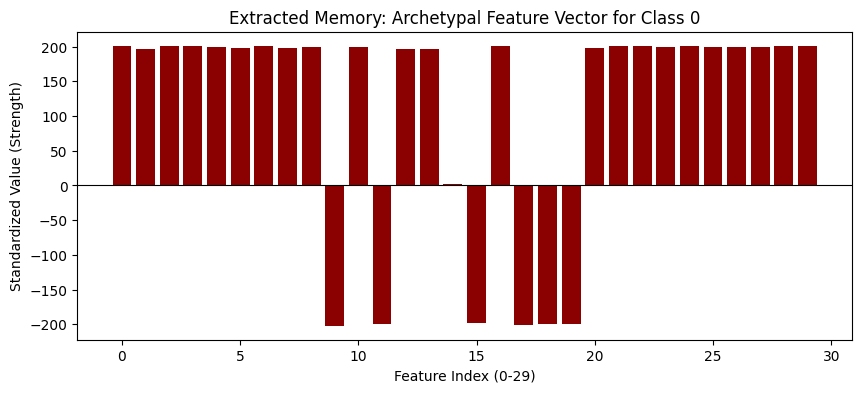

In [40]:
# 4. Extract and Visualize the Reconstructed Vector
reconstructed_vector = dummy_features.detach().numpy().flatten()

plt.figure(figsize=(10, 4))
# Plotting the 30 features as a bar chart
plt.bar(range(30), reconstructed_vector, color='darkred' if target_class_tab == 0 else 'darkgreen')
plt.title(f"Extracted Memory: Archetypal Feature Vector for Class {target_class_tab}")
plt.xlabel("Feature Index (0-29)")
plt.ylabel("Standardized Value (Strength)")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [41]:
# 5. Verification
recon_vec_tensor = torch.tensor(reconstructed_vector).view(1, 30)
with torch.no_grad():
    raw_output = tabular_model(recon_vec_tensor)
    probabilities = F.softmax(raw_output, dim=1)
    predicted_class = torch.argmax(probabilities).item()
    confidence = probabilities[0, predicted_class].item() * 100

print(f"Tabular Verification | Target: {target_class_tab} | Model Predicts: {predicted_class} | Confidence: {confidence:.2f}%\n")

Tabular Verification | Target: 0 | Model Predicts: 0 | Confidence: 100.00%

